# Ecuaciones diferenciales parciales

Una ecuación diferencial parcial de dos variables tiene la siguiente forma:

$$Au_{xx} + Bu_{xy} + Cu_{yy} + F(u_x,u_y,u,x,y) = 0$$

Donde las derivadas parciales se indican mediante los subíndices x y y para las variables independientes y u indica la solución.

Las EDP de segundo orden con dos variables independientes se clasifican como:

1. Parabólicas si $B^2 - 4AC = 0$
2. Hiperbólicas si $B^2 - 4AC > 0$
3. Elípticas si $B^2 - 4AC < 0$

# Funciones parbólicas

La ecuación de calor es un ejemplo de ecuación parabólica:

$$u_t = Du_{xx}$$

Representa la temperatura x medida a lo largo de una placa homegénea unidimensional. La constante $D > 0$ se denomina coeficiente de difusión, representa la difusividad térmica del material que forma la placa. La ecuación modela la propagación del calor desde las regiones de mayor concentración hasta las de menor concentración.

Como puede verse $A = D, C = 0, B = 0$ por lo tanto $B^2 - 4AC = 0$

Al igual que las EDOs, la EDP anterior tiene soluciones infinitas y se requieren condiciones adicionales para determinar una solución particular. Para representar una EDP correctamente pueden emplearse tanto varias combinaciones de condiciones iniciales y de frontera.

Para la ecuación de calor:

$$\begin{cases} u_t = Du_{xx}, \,\,\, a \le x \le b,\,\, t \ge 0 \\ u(x,0) = f(x), \,\,\, a \le x \le b \\ u(a,t) = l(t), \,\,\, t \ge 0 \\ u(b,t) = r(t), \,\,\, t \ge 0  \end{cases}$$

El coeficiente de difusión $D$ controla la tasa de transferencia de calor. $f(x)$ da la distribución de la temperatura inicial a lo largo de la placa. $l(t)$ y $r(t)$ para $t \ge 0$ proporciona la temperatura en los extremos.


# Método de diferencias hacia adelante

$$u_{xx}(x,t) = \frac{1}{h^2} (u(x+h, t) - 2u(x,t) + u(x-h,t))$$

$$u_t(x,t) = \frac{1}{k}(u(x, t + k) - u(x,t))$$

Al sustituir se obtiene:

$$\frac{1}{k}(u(x, t + k) - u(x,t)) = \frac{D}{h^2} (u(x+h, t) - 2u(x,t) + u(x-h,t))$$

Para cada punto $(x_i, t_j)$:

$$\frac{D}{h^2}(w_{i+1,j} - 2w_{i,j} + w_{i-1,j}) = \frac{1}{k}(w_{i, j+1} - w_{i,j})$$

Con el error de truncamiento local dado por $O(k) + O(h^2)$

Si, despejamos $w_{i, j+1}$ dado que queremos avanzar en el tiempo la solución:

$$w_{i, j+1} = w_{i,j} + \frac{kD}{h^2}(w_{i+1,j} - 2w_{i,j} + w_{i-1,j})$$

Se puede definir $\sigma = \frac{Dk}{h^2}$

$$w_{i, j+1} = \sigma w_{i+1,j} + (1 - 2 \sigma) w_{i,j} + \sigma w_{i-1,j}$$

Este método es explícito puesto que existe una manera de determinar los valores nuevos directamente a partir de los valores antes conocidos. Un método que no sea explícito se denomina implícito.










Resuelva la ecuación de calor para:

$$\begin{cases}f(x) = sin(2 \pi x)^2 \\ u(0,t) = (1,t) = 0 \\ D = 1\end{cases}$$

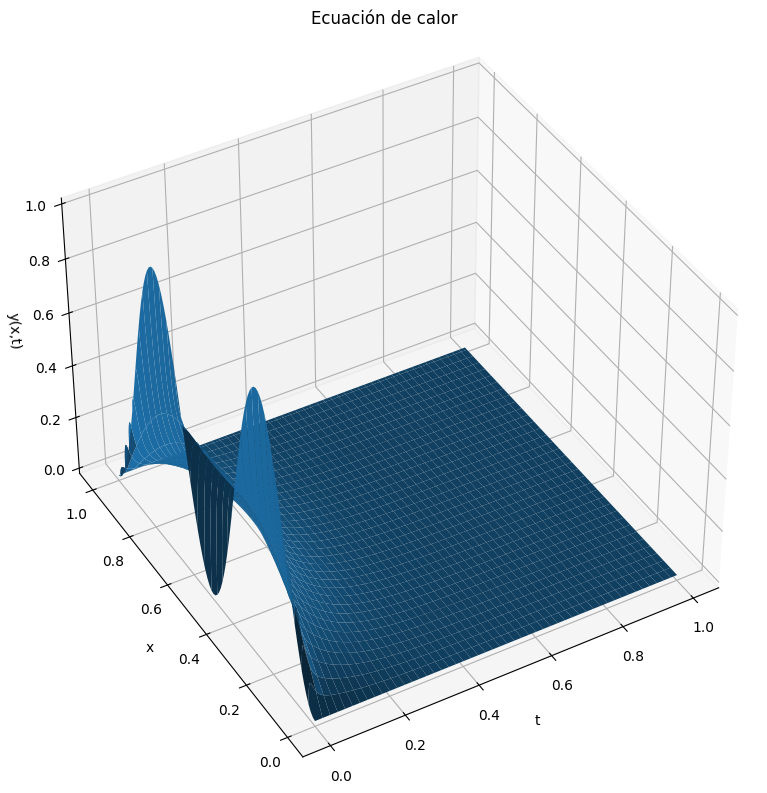

In [73]:
import numpy as np
import matplotlib.pyplot as plt

def f(X):
    return np.sin(2*np.pi*X)**2

def solver_calor(f, a, b, D, L, delta_x, delta_t):
    X = np.arange(0, L + delta_x, delta_x)
    t = np.arange(a, b + delta_t, delta_t)
    n = t.shape[0]
    Y = np.zeros((n, X.shape[0]))
    Y[0] = f(X)

    for i in range(n-1):
        Y[i+1, 1:-1] = Y[i, 1:-1] + (delta_t*D/delta_x**2)*(Y[i, 2:] - 2*Y[i,1:-1] + Y[i, :-2])

    return Y, X, t
a = 0
b = 1
L = 1
D = 1
delta_x = 0.01
delta_t = 0.4*delta_x**2/D

Y, X, t = solver_calor(f, a, b, D, L, delta_x, delta_t)

X_mesh, T_mesh = np.meshgrid(X, t)

fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection = '3d')

ax.set_title('Ecuación de calor')
ax.plot_surface(T_mesh, X_mesh, Y)
ax.set_ylabel('x')
ax.set_xlabel('t')
ax.set_zlabel('y(x,t)')
ax.view_init(40,-120)
plt.tight_layout()
plt.show()




# Análisis de estabilidad del método de las diferencias hacia adelante

A parte de error de truncamiento debido al error de Taylor, existe un magnificación de los errores debido al método mismo. El análisis de estabilidad de Von Neumann mide la magnificación, o amplificación del error. Para un método estable, los tamaños de paso deben elegirse de modo que el factor de magnificación no sea mayor que 1.T

Sea $y_j$ la solución exacta que satisface $y_{j+1} = Ay_j + s_j$ y sea w_j la aproximación calculada que satisface $w{j+1} = Aw_j + s_j$. La diferencia $e_j = w_j - y_j$ satisface:

$$e_j = w_j - y_j = Aw_{j-1} + s_{j-1} - (Ay_{j-1} + s_{j-1}) = Ae_{j-1}$$

Entonces para que los errores no se amplifiquen lo que se necesita es que el radio espectral de la matriz A sea inferior a 1 $\rho (A) \le 1$. Este requisito pone límites al tamaño de paso temporal y espacial.

Una forma de realizar este análisis es introducir un error de forma sinusoidal en la ecuación discreta:

$$e_i^n = G^ne^{ikx_i}$$

Done $k$ es el numero de onda, $e^{ikx_i}$ es el modo Fourier y G el factor de amplificación

Por ejemplo para la aproximación de la solución de la ecuación en diferencias hacia adelante:

$$w_{i, j+1} = w_{i,j} + \frac{kD}{h^2}(w_{i+1,j} - 2w_{i,j} + w_{i-1,j})$$

$$w_{i, j+1} = w_{i,j} + r(w_{i+1,j} - 2w_{i,j} + w_{i-1,j})$$



$$G^{n+1}e^{ikx_i} = G^ne^{ikx_i}  + r(G^ne^{ik(x_i + \Delta x)} - 2G^ne^{ikx_i} + G^ne^{ik(x_i - \Delta x)})$$


$$G^{n+1}e^{ikx_i} = G^ne^{ikx_i}  + rG^ne^{ikx_i}(e^{ik(\Delta x)} - 2 + e^{ik(- \Delta x)})$$

$$G=1+r(-2 + 2cos(k \Delta_x))$$

$$G=1+2r(cos(k \Delta_x) - 1)$$

$$G=1-4r(\frac{1 - cos(k \Delta_x)}{2})$$

$$G=1-4r(sin^2(\frac{k \Delta x}{2}))$$

Queremos que la amplificación cumple $|G| \le 1$

$$-1 \le G \le 1$$

$$-1 \le 1-4r(sin^2(\frac{k \Delta x}{2})) \le 1$$

Para la ecuación de calor $r = \frac{D\Delta t}{(\Delta x)^2}$, dado que $D > 0$, r siempre es positivo.

$$ 1-4r(sin^2(\frac{k \Delta x}{2})) \le 1 $$

$$ -4r(sin^2(\frac{k \Delta x}{2})) \le 0 $$

Siempre se cumple, solo hace falta comprobar la segunda desigualdad:

$$-1 \le 1-4r(sin^2(\frac{k \Delta x}{2}))$$

$$-2 \le -4r(sin^2(\frac{k \Delta x}{2}))$$

$$\frac{1}{2} \ge r(sin^2(\frac{k \Delta x}{2}))$$

$$r(sin^2(\frac{k \Delta x}{2}))  \le \frac{1}{2} $$

Lo más que puede valor $(sin^2(\frac{k \Delta x}{2}))$ es 1, por lo tanto:

$$r \le \frac{1}{2}$$

Por lo tanto la condición CFL es:

$$\frac{D \Delta t}{(\Delta x)^2} \le \frac{1}{2}$$










# Método de diferencias hacia atrás

Se procede de la misma forma, solo que la primera derivada temporal se aproxima con diferencias hacia atrás, es decir:

$$u_t = \frac{u(x, t) - u(x,t - k)}{k} + \frac{k}{2}u_{tt}(x, c0) $$

Al sustituir:

$$\frac{D}{h^2}(w_{i+1,j} - 2w_{i,j} + w_{i-1,j}) = \frac{1}{k}(w_{i, j} - w_{i,j-1}))$$

Con error de truncamiento $O(k) + O(h^2)$

La ecuación se puede reordenar, tomamos $\sigma = \frac{D k}{h^2}$.

$$\frac{D k}{h^2}(w_{i+1,j} - 2w_{i,j} + w_{i-1,j}) = (w_{i, j} - w_{i,j-1})$$

$$\sigma (w_{i+1,j} - 2w_{i,j} + w_{i-1,j}) = (w_{i, j} - w_{i,j-1})$$

$$\sigma w_{i+1,j} - (2\sigma + 1) w_{i,j} + \sigma w_{i-1,j} = - w_{i,j-1}$$

$$-\sigma w_{i+1,j} + (1 + 2\sigma) w_{i,j} - \sigma w_{i-1,j} = w_{i,j-1}$$

Esto puede escribirse como una ecuación matricial de $m$ x $m$ (destacar que esta formulación es implícita):

<center>

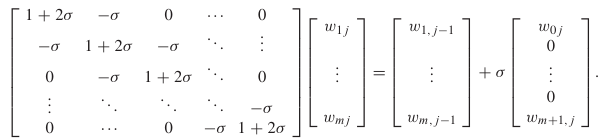

<center>



Al ser una matriz tridiagonal, el mejor método para resolver el sistema es a través del algoritmo de Thomas.

Resuelva la ecuación de calor para:

$$\begin{cases}f(x, 0) = sin(2 \pi x)^2 \\ u(0,t) = (1,t) = 0 \\ D = 1\end{cases}$$

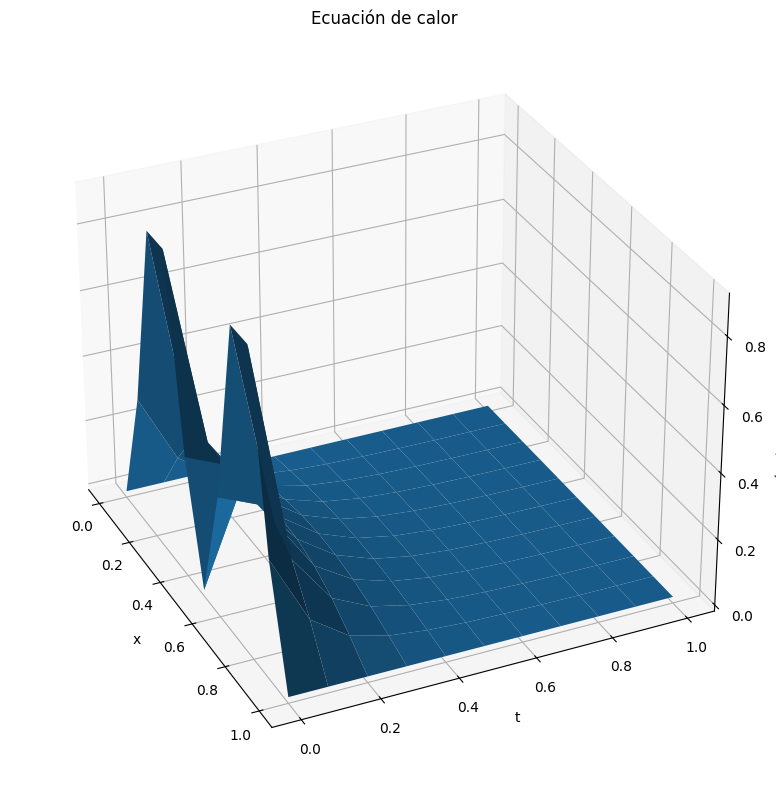

In [134]:
import numpy as np
import matplotlib.pyplot as plt

def f(X):
    return np.sin(2*np.pi*X)**2

def thomas_diagonales(inferior, diagonal, superior, d):
    b = np.copy(diagonal).astype(float)
    a = np.copy(inferior).astype(float)
    c = np.copy(superior).astype(float)
    d = np.copy(d).astype(float)

    n = d.shape[0]

    
    w = np.zeros(n)
     

    for i in range(1, n):
        r = a[i-1]/b[i-1]

        b[i] = b[i] - c[i-1]*r
        d[i] = d[i] - d[i-1]*r

            

    w[n-1] = d[n-1]/b[n-1]

    for i in range(n-2, -1, -1):
        
        w[i] = (d[i] - c[i]*w[i+1])/b[i]

    return w
    
D = 1
delta_x = 0.1
delta_t = 0.1
a = 0
b = 1
fa = lambda t: 0
fb = lambda t: 0
L = 1

def solver_calor_atras(f, a, b, fa, fb, D, L, delta_x, delta_t, solver_matriz):
    X = np.arange(0, L + delta_x, delta_x)
    t = np.arange(a, b + delta_t, delta_t)
    n = t.shape[0]
    U = np.zeros((n, X.shape[0]))

    U[0] = f(X)
    U[0,0] = fa(t[0])
    U[0,-1] = fb(t[0])

    sigma = D*delta_t/delta_x**2

    inferior = np.full(X.shape[0] - 3, -sigma)
    superior = np.full(X.shape[0] - 3, -sigma)
    diagonal = np.full(X.shape[0] - 2, 1 + 2*sigma)

    for i in range(1, n):
        U[i, 0] = fa(t[i])
        U[i, -1] = fb(t[i])

        d = U[i-1, 1:-1].copy()
        d[0] += sigma*fa(t[i])
        d[-1] += sigma*fb(t[i])

        U[i, 1:-1] = solver_matriz(inferior, diagonal, superior, d)

    return U, X, t

U, X, t = solver_calor_atras(f, a, b, fa, fb, D, L, delta_x, delta_t, thomas_diagonales)


X_mesh, T_mesh = np.meshgrid(X, t)

fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection = '3d')

ax.set_title('Ecuación de calor')
ax.plot_surface(X_mesh, T_mesh, U)
ax.set_ylabel('t')
ax.set_xlabel('x')
ax.set_zlabel('u(x,t)')
ax.view_init(elev=30, azim=-25)
plt.tight_layout()
plt.show()



Resuelva la ecuación de calor para:

$$\begin{cases}f(x,0) = e^{-x/2} \\ u(0,t) = e^t \\ (1,t) = e^{t - \frac{1}{2}} \\ D = 4\end{cases}$$

In [132]:

def f(X):
    return np.exp(-X/2)

D = 4
delta_x = 0.1
delta_t = 0.1
a = 0
b = 1
fa = lambda t: np.exp(t)
fb = lambda t: np.exp(t - 0.5)
L = 1

U, X, t = solver_calor_atras(f, a, b, fa, fb, D, L, delta_x, delta_t, thomas_diagonales)

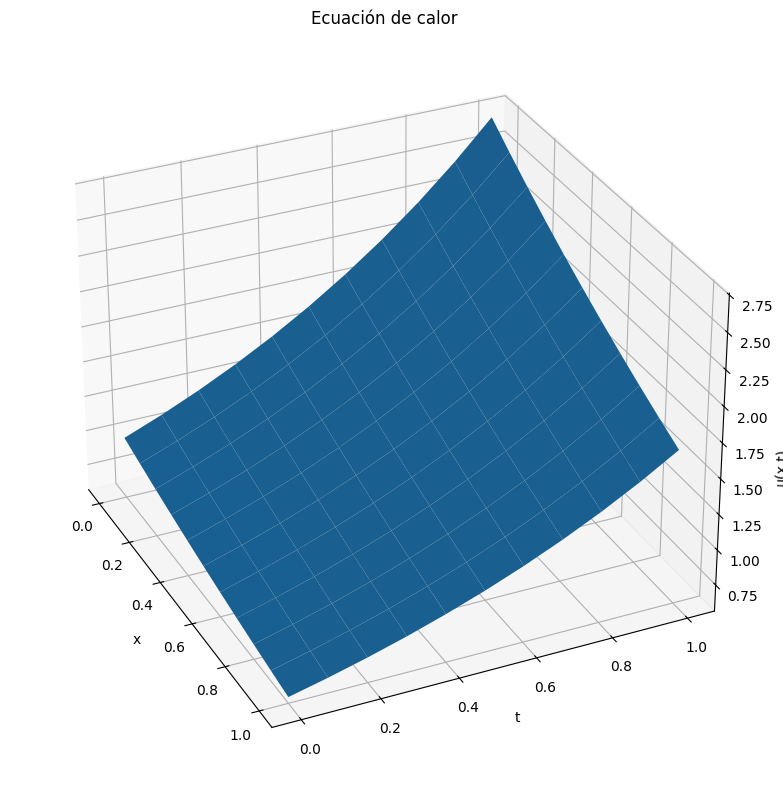

In [133]:
X_mesh, T_mesh = np.meshgrid(X, t)

fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection = '3d')

ax.set_title('Ecuación de calor')
ax.plot_surface(X_mesh, T_mesh, U)
ax.set_ylabel('t')
ax.set_xlabel('x')
ax.set_zlabel('u(x,t)')
ax.view_init(elev=30, azim=-25)
plt.tight_layout()
plt.show()

Para el análisis de estabilidad suponemos un error:

$$e_j = G^ne_{ikx_i}$$

La aproximación es: 

$$\frac{D}{h^2}(w_{i+1,j} - 2w_{i,j} + w_{i-1,j} = \frac{1}{k}(w_{i, j} - w_{i,j-1}))$$

$$\frac{Dk}{h^2}(w_{i+1,j} - 2w_{i,j} + w_{i-1,j} = w_{i, j} - w_{i,j-1}$$

$$r(w_{i+1,j} - 2w_{i,j} + w_{i-1,j}) = w_{i, j} - w_{i,j-1}$$

$$r(G^ne_{ikx_i + \Delta x} - 2G^ne_{ikx_i} + G^ne_{ikx_i - \Delta x}) = G^ne_{ikx_i} - G^{n-1}e_{ikx_i}$$

$$r(e_{ik\Delta x} - 2 + e_{-ik\Delta x}) = 1 - G^{-1}$$

$$r(e_{ik\Delta x} - 2 + e_{-ik\Delta x}) - 1 = - G^{-1}$$

$$G^{-1} = - r(e_{ik\Delta x} - 2 + e_{-ik\Delta x}) + 1 $$

$$G^{-1} = - r(- 2 + 2cos(k \Delta x)) + 1 $$

$$G^{-1} =  2r(1 - cos(k \Delta x)) + 1 $$

$$G^{-1} =  4r(sin^2(\frac{k \Delta x}{2})) + 1 $$

$$G = \frac{1}{4r(sin^2(\frac{k \Delta x}{2})) + 1}$$

$$|G| \le 1$$

$$-1 \le \frac{1}{4r(sin^2(\frac{k \Delta x}{2})) + 1} \le 1$$

Como r es positivo puede verse fácilmente que esta expresión es cierta siempre. Es decir puede usar cualquier valor arbitrario para $\Delta x, \Delta t$ a diferencia del método con diferencia hacia adelante.

Las condiciones de frontera que se han aplicado a la ecuación de calor se denominan condiciones de frontera de Dirichlet. Especifican los valores de la solución $u(x,t)$ en la frontera de la solución. Si se considera la ecuación de calor como un modelo de conducción de calor, esto corresponde a mantener la temperatura en la frontera a un nivel prescrito.

Un tipo de alternativa de condición de frontera corresponde a una frontera aislada. Aquí la temperatura no se especifica, pero se supone que el calor no puede conducirse a través de la frontera. Una condición de Neumann especifica el valor de una derivada en la frontera. Por ejemplo en el dominio $[a,b]$ que requiere $u_x(a,t)=u_x(b,t)=0$ para toda t corresponde a una frontera aislada, o sin flujo. 

# Problema con condiciones de Neumann

Aplica el método de diferencias hacia atrás para resolver la ecuación de calor con condiciones de Neumann:

$$\begin{cases}u_t = u_{xx}\,\,\,\,, 0 \le x \le 1 \,\,\,\,, 0 \le t \le 1 \\ u_{x,0} = sin^2(2 \pi x), \,\,\, 0 \le x \le 1 \\ u_x(0,t) = sin(4 \pi t), \,\,\, 0 \le t \le 1 \\u_x(1,t) = 0, \,\,\, 0 \le t \le 1 \end{cases}$$

Aproximamos a través de diferencias centradas:

$$\frac{\partial u(0,t)}{\partial x} = \frac{u(0+\Delta x, t) - u(0 - \Delta x, t)}{2 \Delta x} = g(t)$$

$$\frac{\partial u(1,t)}{\partial x} = \frac{u(1+\Delta x, t) - u(1 - \Delta x, t)}{2 \Delta x} = g(t)$$

$$w_{1, j} - w_{-1,j} = g(t)2h x$$

$$w_{1, j} = g(t)2h+ w_{-1,j}$$

$$w_{-1,j} = w_{1, j} - g(t)2h$$

Se reemplaza en:

$$-\sigma w_{i+1,j} + (1 + 2\sigma) w_{i,j} - \sigma w_{i-1,j} = w_{i,j-1}$$

Para el primer punto$:

$$-\sigma w_{1,j} + (1 + 2\sigma) w_{0,j} - \sigma w_{-1,j} = w_{0,j-1}$$

$$-\sigma w_{1,j} + (1 + 2\sigma) w_{0,j} - \sigma (w_{1, j} - g(t_j)2h ) = w_{0,j-1}$$

$$-2\sigma w_{1,j} + (1 + 2\sigma) w_{0,j} + \sigma g(t_j)2h = w_{0,j-1}$$

$$-2\sigma w_{1,j} + (1 + 2\sigma) w_{0,j} = w_{0,j-1} - \sigma g(t)2h$$

Para el último:

$$-\sigma (g(t_j)2h + w_{M-1,j}) + (1 + 2\sigma) w_{M,j} - \sigma w_{M-1,j} = w_{M,j-1}$$

$$-\sigma g(t_j)2h + (1 + 2\sigma) w_{M,j} - 2\sigma w_{M-1,j} = w_{M,j-1}$$

$$ (1 + 2\sigma) w_{M,j} - 2\sigma w_{M-1,j} = w_{M,j-1} + \sigma g(t_j)2h$$

La nueva matriz sera:

$$
\begin{bmatrix}
(1 + 2\sigma) & -2 \sigma & 0 & \cdots & 0 \\

-\sigma & (1 +  2\sigma) & -\sigma & \ddots  & \vdots \\

0 & -\sigma & (1 +  2\sigma) & \ddots  & 0 \\

\vdots & \vdots & \ddots & \ddots &  \ddots \\

0 & \cdots & 0 &  -2 \sigma & (1 + 2\sigma) 

\end{bmatrix} \begin{bmatrix} w_{0,j} \\ w_{1,j} \\ \vdots \\ \vdots \\ w_{M,j} \end{bmatrix} = \begin{bmatrix} w_{0,j-1} \\ w_{1,j-1} \\ \vdots \\ \vdots \\ w_{M,j-1} \end{bmatrix} + \sigma \begin{bmatrix} -g(t_j)2h \\ 0 \\ \vdots \\ 0 \\ g(t_j)2h \end{bmatrix}

$$



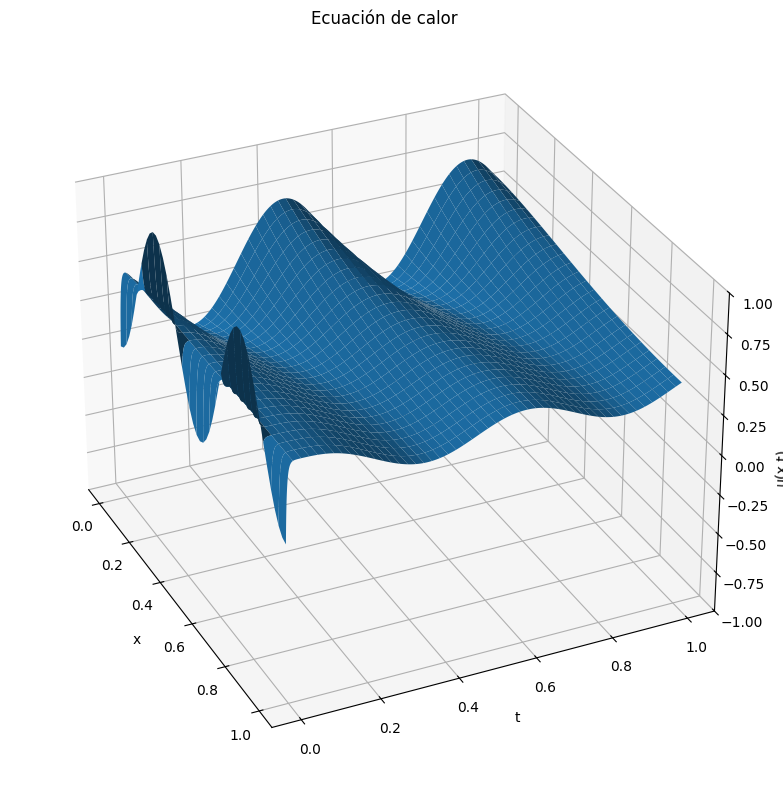

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(X):
    return np.sin(2*np.pi*X)**2

def thomas_diagonales(inferior, diagonal, superior, d):
    b = np.copy(diagonal).astype(float)
    a = np.copy(inferior).astype(float)
    c = np.copy(superior).astype(float)
    d = np.copy(d).astype(float)

    n = d.shape[0]

    
    w = np.zeros(n)
     

    for i in range(1, n):
        r = a[i-1]/b[i-1]

        b[i] = b[i] - c[i-1]*r
        d[i] = d[i] - d[i-1]*r

            

    w[n-1] = d[n-1]/b[n-1]

    for i in range(n-2, -1, -1):
        
        w[i] = (d[i] - c[i]*w[i+1])/b[i]

    return w
    
D = 1.5
delta_x = 0.02
delta_t = 0.0001
a = 0
b = 1
dfa = lambda t: np.sin(4*np.pi*t)
dfb = lambda t: 0
L = 1

def solver_calor_atras(f, a, b, dfa, dfb, D, L, delta_x, delta_t, solver_matriz):
    X = np.arange(0, L + delta_x, delta_x)
    t = np.arange(a, b + delta_t, delta_t)
    n = t.shape[0]
    U = np.zeros((n, X.shape[0]))

    U[0] = f(X)
    

    sigma = D*delta_t/delta_x**2

    inferior = np.full(X.shape[0] - 1, -sigma)
    inferior[-1] = -2*sigma
    
    superior = np.full(X.shape[0] - 1, -sigma)
    superior[0] = -2*sigma

    diagonal = np.full(X.shape[0], 1 + 2*sigma)

    for i in range(1, n):

        d = U[i-1].copy()
        d[0] -= 2*sigma*dfa(t[i])*delta_x
        d[-1] += 2*sigma*dfb(t[i])*delta_x

        U[i] = solver_matriz(inferior, diagonal, superior, d)

    return U, X, t

U, X, t = solver_calor_atras(f, a, b, dfa, dfb, D, L, delta_x, delta_t, thomas_diagonales)


X_mesh, T_mesh = np.meshgrid(X, t)

fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection = '3d')

ax.set_title('Ecuación de calor')
ax.plot_surface(X_mesh, T_mesh, U)
ax.set_ylabel('t')
ax.set_xlabel('x')
ax.set_zlabel('u(x,t)')
ax.set_zlim(-1,1)
ax.view_init(elev=30, azim=-25)
plt.tight_layout()
plt.show()

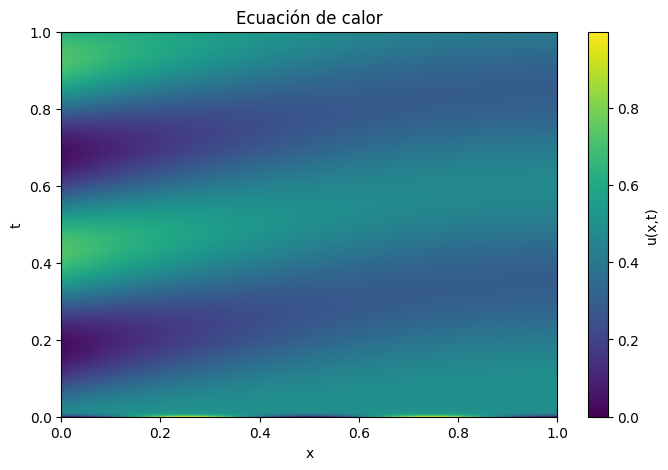

In [156]:
plt.figure(figsize=(8,5))
plt.imshow(
    U,
    aspect='auto',
    origin='lower',
    extent=[0, L, a, b]
)

plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Ecuación de calor')
plt.show()

# Método de Crank-Nicolson

Hasta ahora hemos visto dos métodos, uno explícito a veces estable y otro implícito que es siempre estable. Ambos con errores de tamaño $O(\Delta t + (\ Delta x)^2)$ cuando se estabilizan. El tamaño del paso del tiempo debe ser bastante pequeño para obtener una buena precisión.

El método de Crank-Nicolson es una combinación de los métodos implícitos y explícitos, es incondicionalmente estable y tiene error $O(h^2) + O(k^2)$. 

Crank-Nicolson se deriva al promediar el método de diferencias progresivas en el j-ésimo paso en t:

$$\frac{D}{h^2}(w_{i+1,j} - 2w_{i,j} + w_{i-1,j}) = \frac{1}{k}(w_{i, j+1} - w_{i,j})$$

Y que tiene error de truncamiento:

$$\frac{k}{2}u_{tt} + O(h^2)$$

Con el método de diferencias hacias atrás para el (j + 1)-ésimo paso en t:

$$\sigma (w_{i+1,j + 1} - 2w_{i,j + 1} + w_{i-1,j + 1}) = (w_{i, j + 1} - w_{i,j})$$

Y que tiene error de truncamiento:

$$\frac{-k}{2}u_{tt} + O(h^2)$$

Si suponemos que ambos errores temporales son aproximadamente iguales

$$\frac{\sigma}{2}[(w_{i+1,j} - 2w_{i,j} + w_{i-1,j}) + (w_{i+1,j + 1} - 2w_{i,j + 1} + w_{i-1,j + 1}) ] = (w_{i, j+1} - w_{i,j})$$

Que tiene error de truncamiento $O(k^2 + h^2)$ dado que los términos de error temporal proporcionales a $k$ se eliminan entre ellos.

$$\sigma[(w_{i+1,j} - 2w_{i,j} + w_{i-1,j}) + (w_{i+1,j + 1} - 2w_{i,j + 1} + w_{i-1,j + 1}) ] = 2(w_{i, j+1} - w_{i,j})$$

$$\sigma w_{i-1,j} + (2 - 2\sigma)w_{i,j} + \sigma w_{i+1,j} = -\sigma w_{i-1,j+1} + (2 + 2\sigma)w_{i,j+1} - \sigma w_{i+1,j+1} $$

$$\sigma w_{i-1,j - 1} + (2 - 2\sigma)w_{i,j - 1} + \sigma w_{i+1,j - 1} = -\sigma w_{i-1,j} + (2 + 2\sigma)w_{i,j} - \sigma w_{i+1,j} $$

En forma matricial:

$$Aw_{j+1} = Bw_j + \sigma(s_j + s_{j + 1})$$

También puede verse como: 

$$Aw_{j} = Bw_{j-1} + \sigma(s_{j-1} + s_{j})$$

Donde $s_{j}$ estaría dado por las condiciones de frontera del problema.

Si se realiza el análisis de estabilidad mencionado antes se llegara a la conclusión de que este método al igual que las diferencias hacia atrás es incondicionalmente estable.

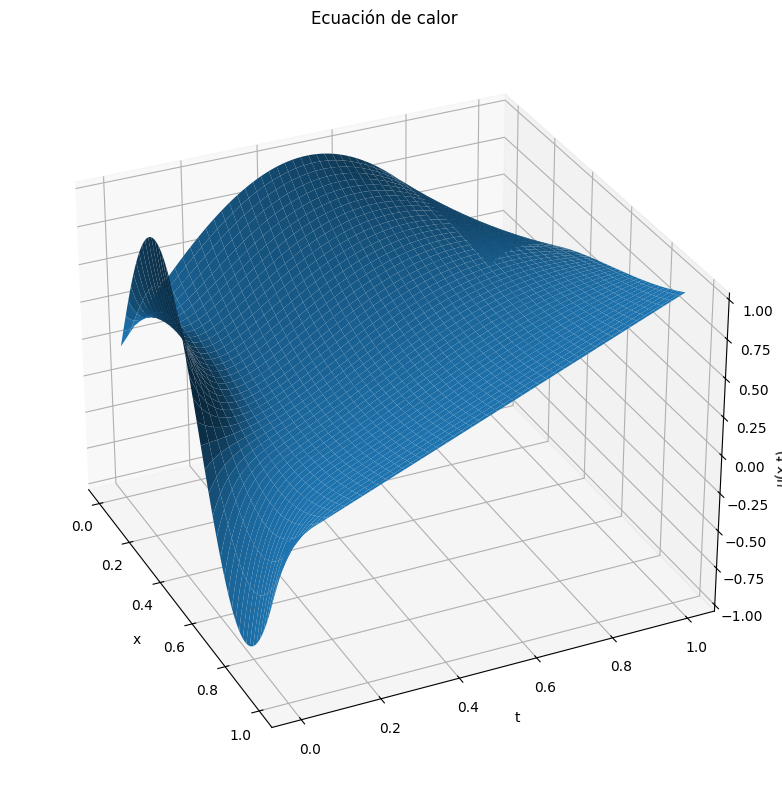

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def u(X):
    return np.sin(2*np.pi*X)

def thomas_diagonales(inferior, diagonal, superior, d):
    b = np.copy(diagonal).astype(float)
    a = np.copy(inferior).astype(float)
    c = np.copy(superior).astype(float)
    d = np.copy(d).astype(float)

    n = d.shape[0]

    
    w = np.zeros(n)
     

    for i in range(1, n):
        r = a[i-1]/b[i-1]

        b[i] = b[i] - c[i-1]*r
        d[i] = d[i] - d[i-1]*r

            

    w[n-1] = d[n-1]/b[n-1]

    for i in range(n-2, -1, -1):
        
        w[i] = (d[i] - c[i]*w[i+1])/b[i]

    return w

def solver_calor_nicolson(f, a, b, fa, fb, D, L, delta_x, delta_t, solver_matriz):
    n =  1 + int((b - a)/delta_t)
    t = np.linspace(a, b, n)
    nx = 1 + int(L/delta_x)
    X = np.linspace(0, L, nx)
    Y = np.zeros((n, nx))
    Y[0] = f(X)
    sigma = D*delta_t/delta_x**2

    Adiagonal = np.full(nx - 2, 2 + 2*sigma)
    Ainferior = np.full(nx - 3, -sigma)
    Asuperior = np.full(nx - 3, -sigma)

    Bdiagonal = np.diag([2 - 2*sigma]*(nx - 2))
    Bsuperior = np.diag([sigma]*(nx - 3), k = 1)
    Binferior = np.diag([sigma]*(nx - 3), k = -1)
    B = Bdiagonal + Bsuperior + Binferior

    for i in range(1, n):
        Y[i, 0] =  fa(t[i])
        Y[i, -1] = fb(t[i])

        
        d = B@Y[i-1, 1:-1]
        d[0] += sigma*(Y[i, 0] + Y[i -1, 0] )
        d[-1] += sigma*(Y[i, -1] + Y[i - 1, -1] )

        Y[i, 1:-1] = solver_matriz(Ainferior, Adiagonal, Asuperior, d)

    return Y, X, t

a = 0
b = 1
fa = lambda t: np.sin(np.pi*t)
fb = lambda t: t
L = 1
D = 0.5
delta_t = 0.001
delta_x = 0.001

U, X, t = solver_calor_nicolson(u, a, b, fa, fb, D, L, delta_x, delta_t, thomas_diagonales)

X_mesh, T_mesh = np.meshgrid(X, t)

fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection = '3d')

ax.set_title('Ecuación de calor')
ax.plot_surface(X_mesh, T_mesh, U)
ax.set_ylabel('t')
ax.set_xlabel('x')
ax.set_zlabel('u(x,t)')
ax.view_init(elev=30, azim=-25)
plt.tight_layout()
plt.show()
    



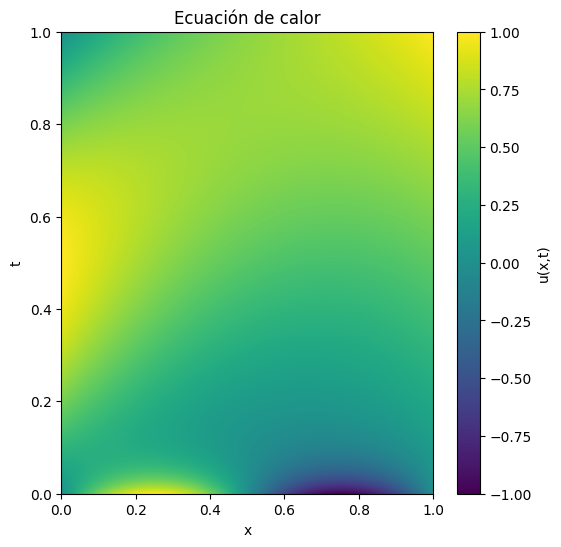

In [ ]:

fig, ax = plt.subplots(figsize = (8,6))
img = ax.imshow(U, origin = 'lower', aspect = 'auto', extent=[0,L, a, b])
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Ecuación de calor')
fig.colorbar(img, ax = ax, label = 'u(x,t)')
plt.tight_layout()
plt.show()